In [114]:
import numpy 
import numba
import numpy as np
import xarray as xr
import netCDF4 as nc
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pystormtracker as pst

In [115]:
tracker = pst.HodgesTracker()

In [191]:
file_loc_01020304 = "vo_NA_feb_04.nc"

data_anatol = xr.open_dataset(file_loc_01020304)

In [192]:
data_anatol

<xarray.Dataset> Size: 8MB
Dimensions:         (valid_time: 20, pressure_level: 1, latitude: 201,
                     longitude: 481)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 160B 2004-02-17 ... 2004-02-2...
    expver          (valid_time) <U4 320B ...
  * pressure_level  (pressure_level) float64 8B 850.0
  * latitude        (latitude) float64 2kB 80.0 79.75 79.5 ... 30.5 30.25 30.0
  * longitude       (longitude) float64 4kB -80.0 -79.75 -79.5 ... 39.75 40.0
    number          int64 8B ...
Data variables:
    vo              (valid_time, pressure_level, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-25T09:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [193]:
lat_s = np.min(data_anatol['latitude'].values)
lat_n = np.max(data_anatol['latitude'].values)
lon_w = np.min(data_anatol['longitude'].values)
lon_e = np.max(data_anatol['longitude'].values)

degrees_for_plotting = np.array([lon_w, lon_e, lat_s, lat_n])

In [194]:
degrees_for_plotting

array([-80.,  40.,  30.,  80.])

In [205]:
help(pst.filter_rsplice)

AttributeError: module 'pystormtracker' has no attribute 'filter_rsplice'

In [196]:
#min leng 1000 km, min holdbarhed 60 min, min vorticitet: 4e-5 
tracker = pst.HodgesTracker(min_track_points=10, taper_points=10, lmin=5, lmax=42, dmax=9.0, min_object_grid_points=18)        
tracks = tracker.track(
    data_anatol,
    "vo",
    detection_mode="max", 
    #object_threshold=2e-5
    
)

for track in tracks:
    if len(track) >= 8:
        print(track.track_id, len(track))

tracks.write("tracks.trackjson")

23 11
47 16
65 11
75 11
113 12
167 13
347 16
605 10
641 10
667 12
673 12


In [204]:
help(tracks.filter_rsplice)

AttributeError: 'Tracks' object has no attribute 'filter_rsplice'

In [197]:
import pandas as pd

def haversine_km(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

frags = sorted(tracks, key=lambda t: t.times[0])
for a, b in zip(frags, frags[1:]):
    t_a_end = pd.to_datetime(a.times[-1])
    t_b_start = pd.to_datetime(b.times[0])
    gap_h = (t_b_start - t_a_end) / pd.Timedelta(hours=1)
    dist_km = haversine_km(a.lons[-1], a.lats[-1], b.lons[0], b.lats[0])
    if 0 < gap_h < 24 and dist_km < 1500:
        print(a.track_id, b.track_id, gap_h, "h gap,", dist_km, "km")

In [208]:
tracks.variables

mappingproxy({'object_gridcell_area_km2': array([4.73858904e+06, 5.84788947e+06, 3.63701573e+06, 4.71249118e+06,
                     4.09875934e+06, 2.82391154e+06, 3.19710032e+06, 3.51665550e+06,
                     3.82207392e+06, 4.00638636e+06, 4.52764992e+06, 1.44090871e+06,
                     2.35744156e+06, 3.72573691e+06, 1.39774787e+06, 3.85610670e+05,
                     3.94850874e+05, 4.62181375e+05, 3.94564144e+05, 1.57767841e+05,
                     4.00638636e+06, 4.52764992e+06, 1.33869288e+04, 1.21319349e+05,
                     5.24255319e+05, 2.76251018e+06, 2.26277533e+06, 3.93722786e+06,
                     1.22252421e+06, 1.13503071e+06, 8.84099367e+05, 6.82882328e+05,
                     5.70504962e+05, 5.27414873e+05, 5.53551288e+05, 6.89736780e+05,
                     7.09686058e+05, 5.20703777e+05, 3.93722786e+06, 2.35744156e+06,
                     3.72573691e+06, 2.48021985e+06, 3.28615080e+06, 3.75402474e+06,
                     1.21376102e+06, 

In [199]:
first = next(iter(tracks))
print(type(first), [a for a in dir(first) if not a.startswith("_")])


<class 'pystormtracker.models.tracks.Track'> ['abs_dist', 'lats', 'lons', 'point_slice', 'times', 'track_id', 'variables']


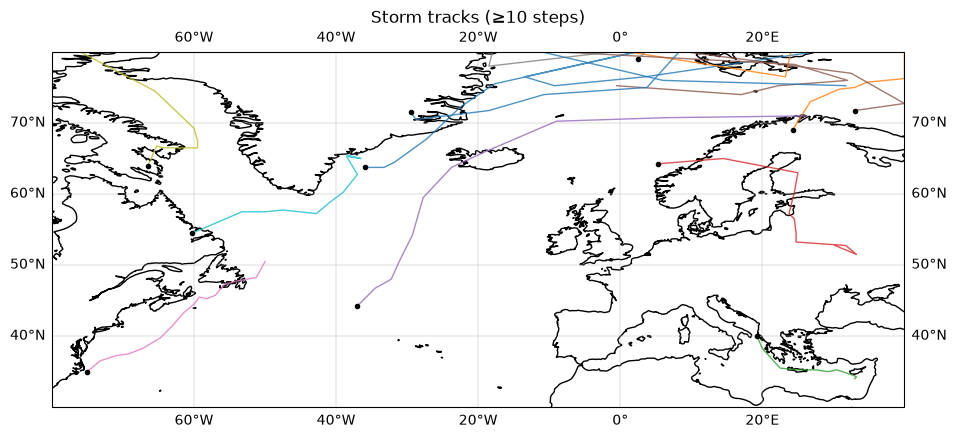

In [200]:
def split_at_dateline(lons, lats):
    """Insert NaNs where a track jumps across the 0/360 or ±180 seam."""
    lons = np.asarray(lons, dtype=float)
    lats = np.asarray(lats, dtype=float)
    jumps = np.where(np.abs(np.diff(lons)) > 180)[0] + 1
    return np.insert(lons, jumps, np.nan), np.insert(lats, jumps, np.nan)

min_len = 10  # drop short-lived features

fig = plt.figure(figsize=(11, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.3)
ax.set_extent(degrees_for_plotting, crs=ccrs.PlateCarree())

for track in tracks:
    if len(track) < min_len:
        continue
    lons, lats = split_at_dateline(track.lons, track.lats)
    ax.plot(lons, lats, transform=ccrs.PlateCarree(), lw=1, alpha=0.8)
    ax.plot(lons[0], lats[0], "o", ms=3, color="k", transform=ccrs.PlateCarree()) 

ax.set_title(f"Storm tracks (≥{min_len} steps)")
plt.savefig("tracks.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
#Max vorticity for each track

ranking_

TypeError: Dimensions of C (83, 225) should be one smaller than X(481) and Y(201) while using shading='flat' see help(pcolormesh)

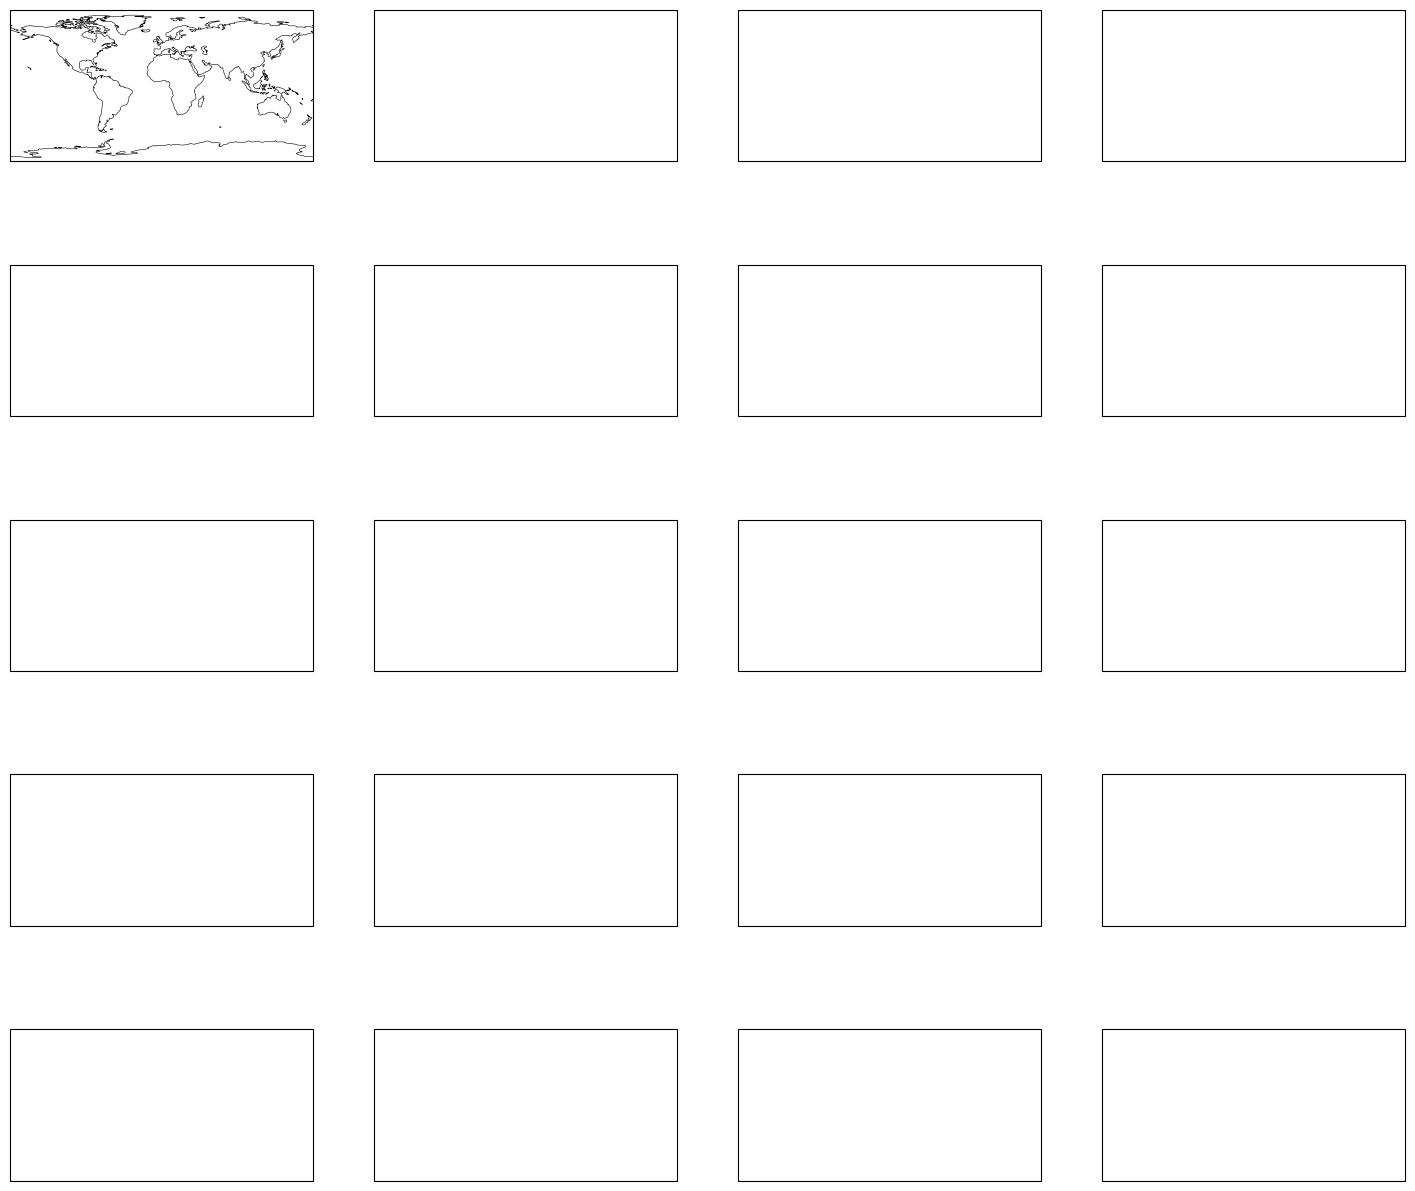

In [206]:
#plotting the vorticity field with the tracks overlayed

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd

times = pd.to_datetime(vor.time.values)
n = len(times)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(4.5 * ncols, 3.2 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

vmax = float(np.abs(vor).quantile(0.995))   # shared color scale across panels

for i, (ax, t) in enumerate(zip(axes.flat, times)):
    field = vor.isel(time=i)
    ax.coastlines(linewidth=0.4)
    ax.pcolormesh(
        data_anatol.longitude, data_anatol.latitude, field,
        transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-vmax, vmax=vmax,
    )
    ax.set_title(t.strftime("%d %b %H:%M"), fontsize=9)
    ax.set_extent(degrees_for_plotting, crs=ccrs.PlateCarree())

    # overlay every track's point at this timestep, colored by track_id
    for tr in tracks:
        tr_times = pd.to_datetime(np.asarray(tr.times))
        match = np.where(tr_times == t)[0]
        if len(match):
            j = match[0]
            ax.plot(tr.lons[j], tr.lats[j], "o", ms=4, mec="k", mfc="yellow",
                     transform=ccrs.PlateCarree())
            ax.annotate(str(tr.track_id), (tr.lons[j], tr.lats[j]),
                        fontsize=6, xytext=(2, 2), textcoords="offset points")
            ax.set_extent(degrees_for_plotting, crs=ccrs.PlateCarree())

for ax in axes.flat[n:]:
    ax.axis("off")

fig.tight_layout()
#plt.savefig("vorticity_timeseries.png", dpi=130)

In [164]:
all_track_times = pd.to_datetime(np.concatenate([np.asarray(t.times) for t in tracks]), unit="ms")
overlap = np.isin(all_track_times, times)

print(f"{overlap.sum()} of {len(all_track_times)} track timestamps found in vor's times")
print(all_track_times[0], times[0])

376 of 376 track timestamps found in vor's times
1999-12-03 12:00:00 1999-12-01 00:00:00


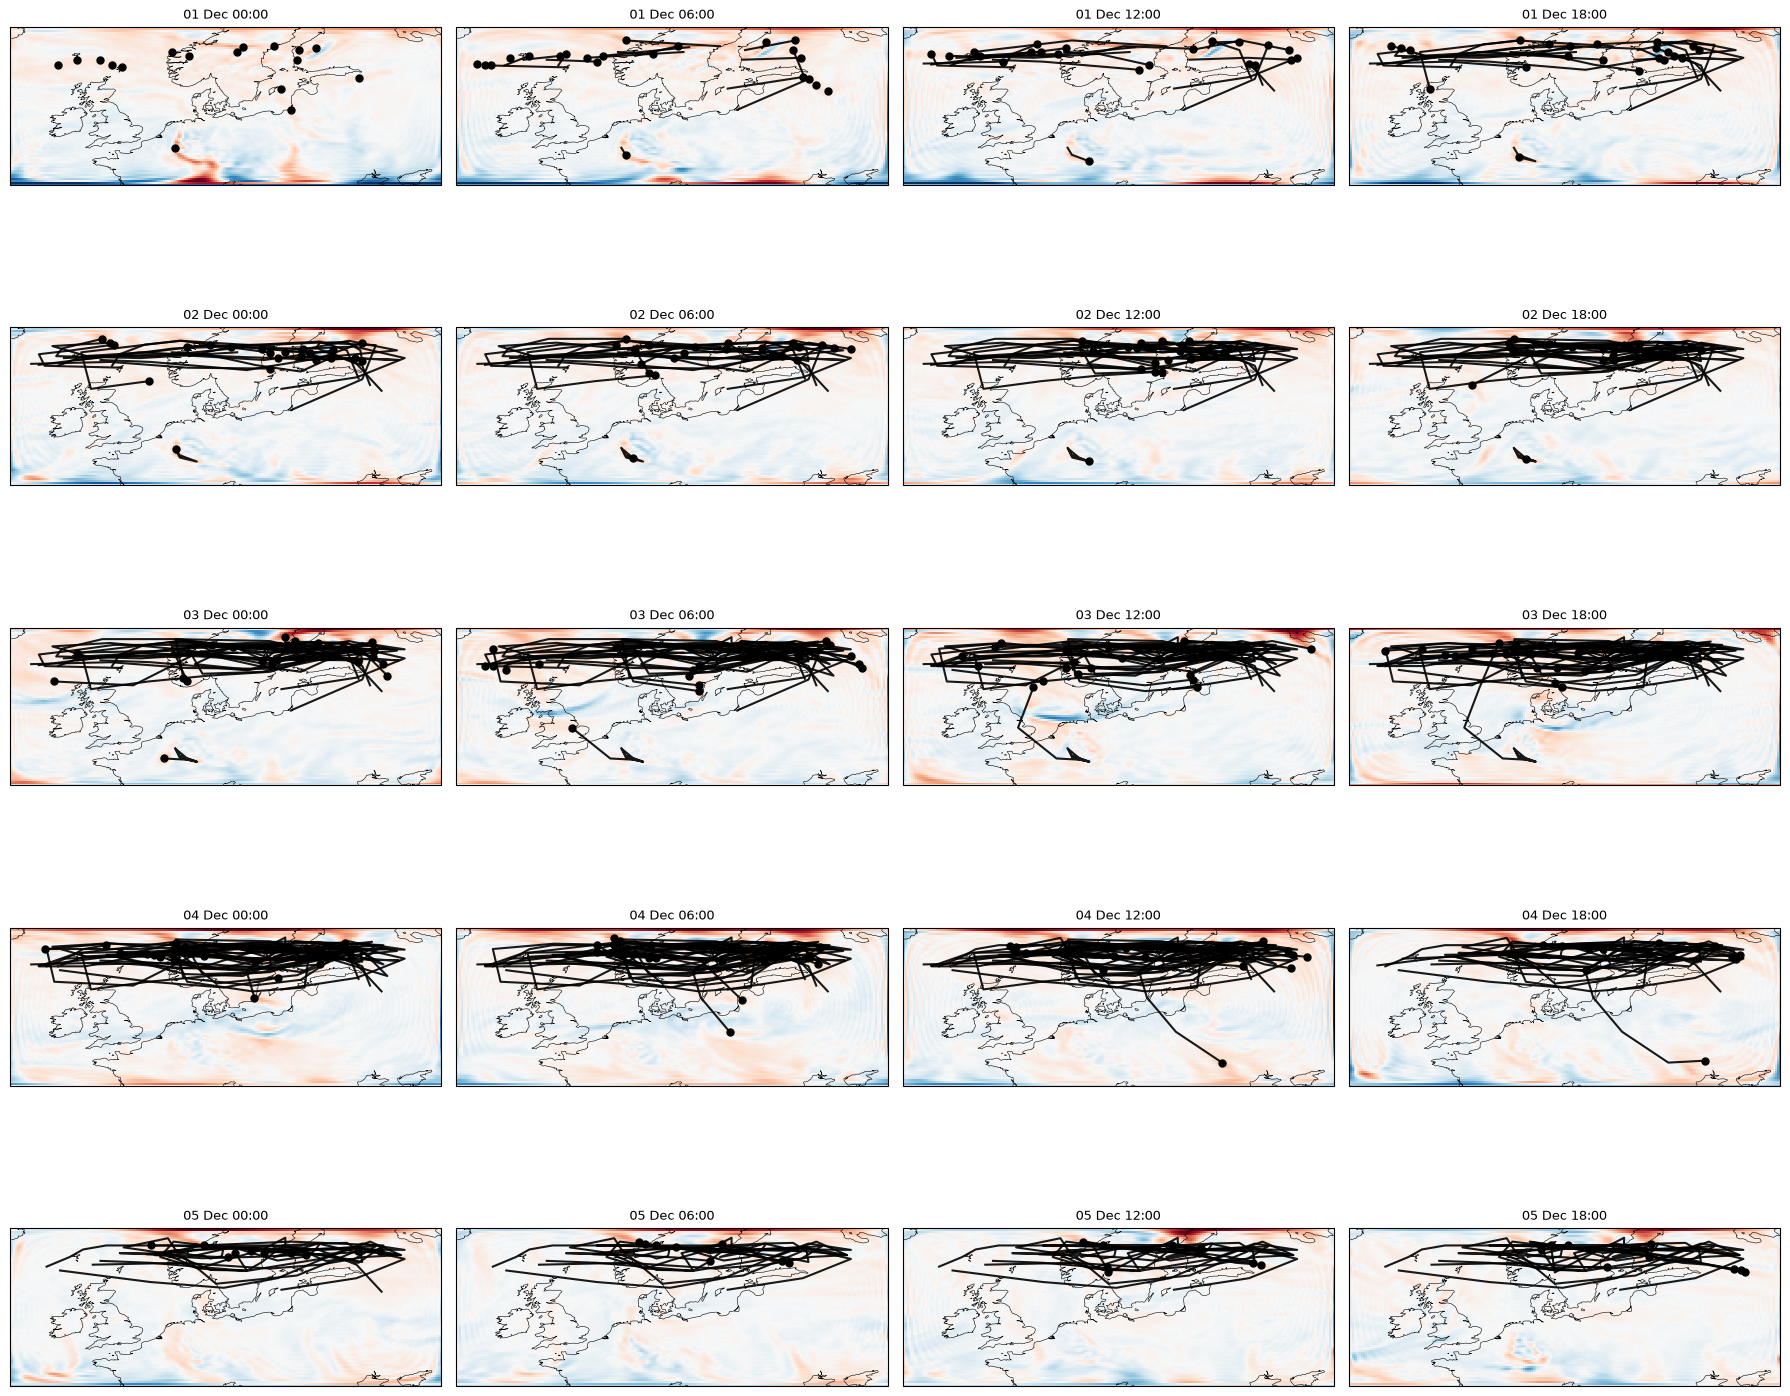

In [165]:
fig, axes = plt.subplots(
    nrows, ncols, figsize=(4.5 * ncols, 3.2 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for i, (ax, t) in enumerate(zip(axes.flat, times)):
    field = vor.isel(time=i)
    ax.coastlines(linewidth=0.4)
    ax.pcolormesh(vor.longitude, vor.latitude, field,
                   transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(t.strftime("%d %b %H:%M"), fontsize=9)
    ax.set_extent([lon_w, lon_e, lat_s, lat_n], crs=ccrs.PlateCarree())

    for tr in tracks:
        if len(tr) < min_len:
            continue
        tr_times = pd.to_datetime(np.asarray(tr.times), unit="ms").floor("h")
        match = np.where(tr_times == t.floor("h"))[0]
        if not len(match):
            continue
        j = match[0]

        # path so far: from track start up to (and including) this timestep
        lons_so_far, lats_so_far = split_at_dateline(tr.lons[:j+1], tr.lats[:j+1])
        ax.plot(lons_so_far, lats_so_far, transform=ccrs.PlateCarree(),
                 lw=1.5, alpha=0.9, zorder=5, color="k")

        # current position, live
        ax.plot(tr.lons[j], tr.lats[j], "o", ms=5, color="k",
                 transform=ccrs.PlateCarree(), zorder=6)
        ax.set_extent([lon_w, lon_e, lat_s, lat_n], crs=ccrs.PlateCarree())

for ax in axes.flat[n:]:
    ax.axis("off")
fig.tight_layout()